# Rock physics 4 innlevering 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import rockphypy as rp 
from rockphypy import utils as rputils
from rockphypy import GM

# Question 2

Effective stress σ' = 20.00 MPa
x = φ/φc = 0.8333
K_HM  = 2.015 GPa
μ_HM  = 2.967 GPa
ζ     = 2.605 GPa
K_dry = 3.006 GPa
μ_dry = 3.925 GPa
ρ_dry = 1855.0 kg/m³
Vs    = 1455 m/s (1.45 km/s)
Vp    = 2108 m/s (2.11 km/s)
n   K_dry(GPa)   Mu_dry(GPa)   Vs(m/s)   Vp(m/s)
 3      1.493        1.924      1018.5     1479.2
 4      1.797        2.322      1118.8     1624.0
 5      2.072        2.685      1203.0     1745.5
 6      2.327        3.022      1276.3     1851.1
 7      2.566        3.338      1341.5     1945.0
 8      2.792        3.639      1400.5     2029.9
 9      3.006        3.925      1454.6     2107.6
10      3.211        4.199      1504.6     2179.3
11      3.408        4.463      1551.2     2246.2


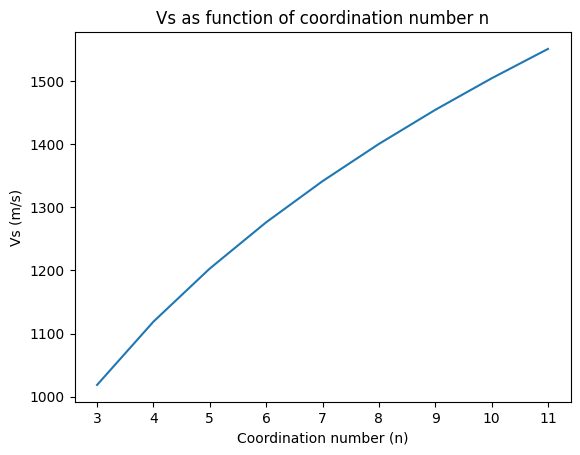

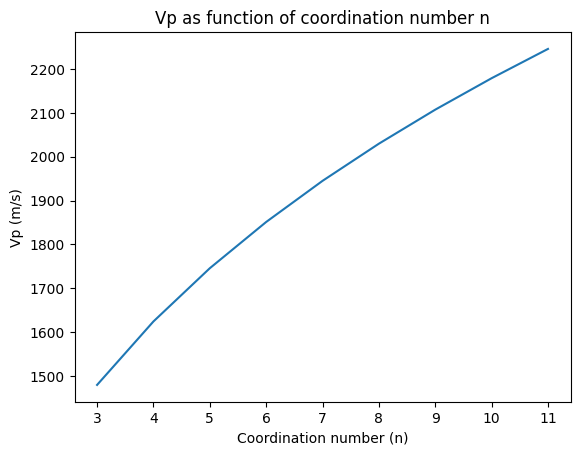

(array([ 3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([1479.15661327, 1624.02661061, 1745.54404028, 1851.11978301,
        1945.0000616 , 2029.87102959, 2107.55231254, 2179.34016694,
        2246.19439858]),
 array([1018.51297479, 1118.80950768, 1203.04395363, 1276.30883242,
        1341.52247789, 1400.53133489, 1454.58642373, 1504.57910432,
        1551.16950447]))

In [12]:
def soft_sand_uncemented_vpvs(
    phi=0.30,
    sigma_v_mpa=40.0,
    pp_mpa=20.0,
    Ks_gpa=37.0,
    mus_gpa=44.0,
    nu=0.06,
    phi_c=0.36,
    Cn=9.0,
    rho_s_kgm3=2650.0,
    verbose=True,
):
    """
    Uncemented (soft-sand) dry-frame model:
      1) Effective stress: sigma' = sigma_v - Pp
      2) Hertz–Mindlin at critical porosity phi_c -> K_HM, mu_HM
      3) Modified lower Hashin–Shtrikman to porosity phi -> K_dry, mu_dry
      4) Dry density and velocities -> Vs, Vp
    """

    # --- 1) Effective stress ---
    sigma_eff_mpa = sigma_v_mpa - pp_mpa
    if sigma_eff_mpa <= 0:
        raise ValueError(f"Effective stress must be > 0 MPa. Got {sigma_eff_mpa:.3f} MPa")

    # Convert units to Pa for Hertz–Mindlin
    sigma_eff_pa = sigma_eff_mpa * 1e6
    mu_s_pa = mus_gpa * 1e9
    K_s_pa = Ks_gpa * 1e9

    # --- 2) Hertz–Mindlin at critical porosity ---
    A = (Cn**2) * (1 - phi_c)**2 * (mu_s_pa**2) / (18 * np.pi**2 * (1 - nu)**2)
    K_HM_pa = (A * sigma_eff_pa) ** (1/3)

    B = (3 * (Cn**2) * (1 - phi_c)**2 * (mu_s_pa**2)) / (2 * np.pi**2 * (1 - nu)**2)
    mu_HM_pa = ((5 - 4*nu) / (5 * (2 - nu))) * (B * sigma_eff_pa) ** (1/3)

    # --- 3) Soft-sand (modified lower HS) from phi_c to phi ---
    if not (0 < phi < phi_c):
        raise ValueError(f"Expected 0 < phi < phi_c. Got phi={phi}, phi_c={phi_c}")

    x = phi / phi_c
    zeta_pa = mu_HM_pa * (9*K_HM_pa + 8*mu_HM_pa) / (6*(K_HM_pa + 2*mu_HM_pa))

    K_dry_pa = (
        1.0 / (
            x / (K_HM_pa + (4/3)*mu_HM_pa)
            + (1-x) / (K_s_pa + (4/3)*mu_HM_pa)
        )
        - (4/3)*mu_HM_pa
    )

    mu_dry_pa = (
        1.0 / (
            x / (mu_HM_pa + zeta_pa)
            + (1-x) / (mu_s_pa + zeta_pa)
        )
        - zeta_pa
    )

    # --- 4) Density and velocities (dry, ignore air density) ---
    rho_dry = (1 - phi) * rho_s_kgm3
    Vs = np.sqrt(mu_dry_pa / rho_dry)
    Vp = np.sqrt((K_dry_pa + (4/3)*mu_dry_pa) / rho_dry)

    out = {
        "sigma_eff_MPa": sigma_eff_mpa,
        "K_HM_GPa": K_HM_pa / 1e9,
        "mu_HM_GPa": mu_HM_pa / 1e9,
        "zeta_GPa": zeta_pa / 1e9,
        "K_dry_GPa": K_dry_pa / 1e9,
        "mu_dry_GPa": mu_dry_pa / 1e9,
        "rho_dry_kgm3": rho_dry,
        "Vs_ms": Vs,
        "Vp_ms": Vp,
        "Vs_kms": Vs / 1000,
        "Vp_kms": Vp / 1000,
        "Cn": Cn,
        "x_phi_over_phic": x,
    }

    if verbose:
        print(f"Effective stress σ' = {out['sigma_eff_MPa']:.2f} MPa")
        print(f"x = φ/φc = {out['x_phi_over_phic']:.4f}")
        print(f"K_HM  = {out['K_HM_GPa']:.3f} GPa")
        print(f"μ_HM  = {out['mu_HM_GPa']:.3f} GPa")
        print(f"ζ     = {out['zeta_GPa']:.3f} GPa")
        print(f"K_dry = {out['K_dry_GPa']:.3f} GPa")
        print(f"μ_dry = {out['mu_dry_GPa']:.3f} GPa")
        print(f"ρ_dry = {out['rho_dry_kgm3']:.1f} kg/m³")
        print(f"Vs    = {out['Vs_ms']:.0f} m/s ({out['Vs_kms']:.2f} km/s)")
        print(f"Vp    = {out['Vp_ms']:.0f} m/s ({out['Vp_kms']:.2f} km/s)")

    return out


def plot_vp_vs_vs_n(
    n_min=3,
    n_max=11,
    **model_kwargs,
):
    """
    Runs soft_sand_uncemented_vpvs for Cn = n_min..n_max,
    prints a table, and plots Vs(n) and Vp(n).
    """
    n_values = np.arange(n_min, n_max + 1)

    Vp_vals, Vs_vals = [], []
    Kdry_vals, Mudry_vals = [], []

    print("n   K_dry(GPa)   Mu_dry(GPa)   Vs(m/s)   Vp(m/s)")
    for n in n_values:
        out = soft_sand_uncemented_vpvs(Cn=float(n), verbose=False, **model_kwargs)
        Kdry_vals.append(out["K_dry_GPa"])
        Mudry_vals.append(out["mu_dry_GPa"])
        Vs_vals.append(out["Vs_ms"])
        Vp_vals.append(out["Vp_ms"])
        print(f"{n:2d}   {out['K_dry_GPa']:8.3f}     {out['mu_dry_GPa']:8.3f}    {out['Vs_ms']:8.1f}   {out['Vp_ms']:8.1f}")

    Vp_vals = np.array(Vp_vals)
    Vs_vals = np.array(Vs_vals)

    # Plot Vs vs n
    plt.figure()
    plt.plot(n_values, Vs_vals)
    plt.xlabel("Coordination number (n)")
    plt.ylabel("Vs (m/s)")
    plt.title("Vs as function of coordination number n")
    plt.show()

    # Plot Vp vs n
    plt.figure()
    plt.plot(n_values, Vp_vals)
    plt.xlabel("Coordination number (n)")
    plt.ylabel("Vp (m/s)")
    plt.title("Vp as function of coordination number n")
    plt.show()

    return n_values, Vp_vals, Vs_vals


# --- 1) Single run (prints the detailed numbers) ---
out = soft_sand_uncemented_vpvs(
    phi=0.30,
    sigma_v_mpa=40,
    pp_mpa=20,
    Ks_gpa=37,
    mus_gpa=44,
    nu=0.06,
    phi_c=0.36,
    Cn=9,
    rho_s_kgm3=2650,
    verbose=True
)

# --- 2) Sweep n=3..11 (prints a table + plots Vs(n) and Vp(n)) ---
plot_vp_vs_vs_n(
    n_min=3,
    n_max=11,
    phi=0.30,
    sigma_v_mpa=40,
    pp_mpa=20,
    Ks_gpa=37,
    mus_gpa=44,
    nu=0.06,
    phi_c=0.36,
    rho_s_kgm3=2650
)


# Question 3

In [13]:
# ----------------------------
# Inputs (from the problem)
# ----------------------------
phi = 0.20          # porosity
Kdry = 12.0         # GPa
Ks = 36.0           # GPa (mineral / matrix bulk modulus K0)

# Fluids (given as Batzle–Wang results in the task text)
K_gas = 0.133       # GPa
rho_gas = 0.336     # g/cm3

K_wat = 3.013       # GPa
rho_wat = 1.055     # g/cm3

# Mineral density (not given in the problem statement; quartz typical)
rho_s = 2.65        # g/cm3


# ----------------------------
# Gassmann (bulk modulus only)
# ----------------------------
def gassmann_Ksat(Kdry, Ks, Kf, phi):
    """
    Gassmann bulk modulus:
    Ksat = Kdry + ( (1 - Kdry/Ks)^2 ) / ( phi/Kf + (1-phi)/Ks - Kdry/Ks^2 )
    All K in same units (here GPa).
    """
    term = (1.0 - Kdry / Ks)
    denom = (phi / Kf) + ((1.0 - phi) / Ks) - (Kdry / (Ks**2))
    return Kdry + (term**2) / denom


def bulk_density(rho_s, rho_f, phi):
    """rho_bulk = (1-phi)*rho_s + phi*rho_f  (g/cm3 if inputs are g/cm3)."""
    return (1.0 - phi) * rho_s + phi * rho_f


# ----------------------------
# Results
# ----------------------------
Ksat_gas = gassmann_Ksat(Kdry, Ks, K_gas, phi)
Ksat_wat = gassmann_Ksat(Kdry, Ks, K_wat, phi)

rho_sat_gas = bulk_density(rho_s, rho_gas, phi)
rho_sat_wat = bulk_density(rho_s, rho_wat, phi)

print("=== Gassmann saturation results (bulk modulus + density) ===")
print(f"Inputs: phi={phi:.2f}, Kdry={Kdry:.3f} GPa, Ks={Ks:.3f} GPa, rho_s={rho_s:.3f} g/cc\n")

print("Gas-saturated:")
print(f"  Kf   = {K_gas:.3f} GPa, rho_f = {rho_gas:.3f} g/cc")
print(f"  Ksat = {Ksat_gas:.3f} GPa")
print(f"  rho  = {rho_sat_gas:.3f} g/cc\n")

print("Water-saturated:")
print(f"  Kf   = {K_wat:.3f} GPa, rho_f = {rho_wat:.3f} g/cc")
print(f"  Ksat = {Ksat_wat:.3f} GPa")
print(f"  rho  = {rho_sat_wat:.3f} g/cc")


=== Gassmann saturation results (bulk modulus + density) ===
Inputs: phi=0.20, Kdry=12.000 GPa, Ks=36.000 GPa, rho_s=2.650 g/cc

Gas-saturated:
  Kf   = 0.133 GPa, rho_f = 0.336 g/cc
  Ksat = 12.293 GPa
  rho  = 2.187 g/cc

Water-saturated:
  Kf   = 3.013 GPa, rho_f = 1.055 g/cc
  Ksat = 17.602 GPa
  rho  = 2.331 g/cc
